In [ ]:
# ============================================================
# Package versions
# ============================================================
# Python:      3.9.23
# NumPy:       2.0.2
# pandas:      2.3.3
# PyTorch:     2.8.0+cu126
# seaborn:     0.13.2
# matplotlib:  3.9.4
# UMAP:        0.5.9.post2
# scikit-learn:1.6.1
# scotplus:    1.0.2

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scotplus.solvers import SinkhornSolver
from scotplus.utils.alignment import compute_graph_distances, get_barycentre, FOSCTTM
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set seeds for Reproducibility
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# Check device
print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"CUDNN version: {torch.backends.cudnn.version()}")

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
torch.backends.cudnn.benchmark = True
print("Using device:", device)

Torch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
CUDNN version: 91002
Using device: cuda:0


In [7]:
# Paths setting
script_dir = os.getcwd()
IN_DIR = os.path.join(script_dir, "processed_data")
RNA_FILE = os.path.join(IN_DIR, "Processed_transcriptomics.csv")
PROT_FILE = os.path.join(IN_DIR, "Processed_proteomics.csv")
RNA_META = os.path.join(IN_DIR, "Processed_transcriptomics_metadata.csv")
PROT_META = os.path.join(IN_DIR, "Processed_proteomics_metadata.csv")
OUT_DIR = os.path.join(script_dir, "aligned_data")
os.makedirs(OUT_DIR, exist_ok=True)

In [9]:
# Preprocessed data loading
rna_df = pd.read_csv(RNA_FILE, index_col=0)
prot_df = pd.read_csv(PROT_FILE, index_col=0)

rna = rna_df.T.copy()
prot = prot_df.T.copy()

print("RNA shape (samples x features):", rna.shape)
print("Proteomics shape (samples x features):", prot.shape)

# Sort samples for reproducibility
rna = rna.sort_index()
prot = prot.sort_index()

RNA shape (samples x features): (82, 1500)
Proteomics shape (samples x features): (68, 1500)


In [11]:
# Metadata loading
rna_meta = pd.read_csv(RNA_META)
prot_meta = pd.read_csv(PROT_META)

if "SampleID" not in rna_meta.columns or "SampleID" not in prot_meta.columns:
    raise ValueError("Both metadata files must contain a 'SampleID' column.")

rna_meta = rna_meta.set_index("SampleID")
prot_meta = prot_meta.set_index("SampleID")

# Subset to matrix sample order
missing_rna_meta = sorted(set(rna.index) - set(rna_meta.index))
missing_prot_meta = sorted(set(prot.index) - set(prot_meta.index))

if missing_rna_meta:
    raise ValueError(f"RNA metadata missing SampleID(s): {missing_rna_meta[:10]}")
if missing_prot_meta:
    raise ValueError(f"Proteomics metadata missing SampleID(s): {missing_prot_meta[:10]}")

rna_meta = rna_meta.loc[rna.index].copy()
prot_meta = prot_meta.loc[prot.index].copy()

print("\nRNA metadata preview:")
print(rna_meta.head())
print("\nProteomics metadata preview:")
print(prot_meta.head())

# Shared IDs for benchmark evaluation only
common_true = sorted(set(rna.index).intersection(set(prot.index)))
print("\nShared true paired sample count:", len(common_true))

if len(common_true) == 0:
    raise ValueError("No shared SampleID values between RNA and proteomics. Cannot benchmark with FOSCTTM.")


RNA metadata preview:
            Chip CellLine  DetectedGenes5  LibrarySize  sizeFactor
05J_C10_A10  05J      C10            4962      2463839    1.625119
05J_C10_A11  05J      C10            5755      2057977    1.391330
05J_C10_A2   05J      C10            5866      3988093    2.506477
05J_C10_A3   05J      C10            6044      2288517    1.637505
05J_C10_A4   05J      C10            6131      2295137    1.563822

Proteomics metadata preview:
            Chip CellLine  DetectedProteins
05J_C10_A10  05J      C10              2564
05J_C10_A11  05J      C10              2754
05J_C10_A2   05J      C10              2737
05J_C10_A3   05J      C10              2397
05J_C10_A4   05J      C10              2652

Shared true paired sample count: 61


In [13]:
# Keeping labels for UMPA projection use
if "CellLine" not in rna_meta.columns or "CellLine" not in prot_meta.columns:
    raise ValueError("Metadata must contain a 'CellLine' column for labels.")

rna_labels = rna_meta["CellLine"].to_numpy()
prot_labels = prot_meta["CellLine"].to_numpy()

print("\nRNA CellLine counts:")
print(pd.Series(rna_labels).value_counts())
print("\nProteomics CellLine counts:")
print(pd.Series(prot_labels).value_counts())

# Preserve names before matrix conversion
rna_features = rna.columns.to_numpy()
prot_features = prot.columns.to_numpy()
rna_cells = rna.index.to_numpy()
prot_cells = prot.index.to_numpy()


RNA CellLine counts:
C10     43
SVEC    39
Name: count, dtype: int64

Proteomics CellLine counts:
SVEC    37
C10     31
Name: count, dtype: int64


In [15]:
# NA Handling
print("\nNA counts before imputation:")
print("RNA NA count:", int(rna.isna().sum().sum()))
print("Proteomics NA count:", int(prot.isna().sum().sum()))

if rna.isna().sum().sum() > 0:
    warnings.warn("RNA contains NA values; filling feature-wise medians, then 0 if needed.")
    rna = rna.apply(lambda x: x.fillna(x.median()), axis=0).fillna(0)

# Proteomics - feature-wise median imputation
if prot.isna().sum().sum() > 0:
    prot = prot.apply(lambda x: x.fillna(x.median()), axis=0).fillna(0)

print("\nNA counts after imputation:")
print("RNA NA count:", int(rna.isna().sum().sum()))
print("Proteomics NA count:", int(prot.isna().sum().sum()))


NA counts before imputation:
RNA NA count: 0
Proteomics NA count: 20750

NA counts after imputation:
RNA NA count: 0
Proteomics NA count: 0


In [16]:
# Feature-wise scaling for SCOT+ geometry
rna_mtx = rna.to_numpy(dtype=np.float32)
prot_mtx = prot.to_numpy(dtype=np.float32)

rna_mtx = StandardScaler().fit_transform(rna_mtx).astype(np.float32)
prot_mtx = StandardScaler().fit_transform(prot_mtx).astype(np.float32)

assert np.isfinite(rna_mtx).all(), "RNA still contains NaN/Inf after scaling"
assert np.isfinite(prot_mtx).all(), "Proteomics still contains NaN/Inf after scaling"

C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\49152\anaconda3\envs\scotplus\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


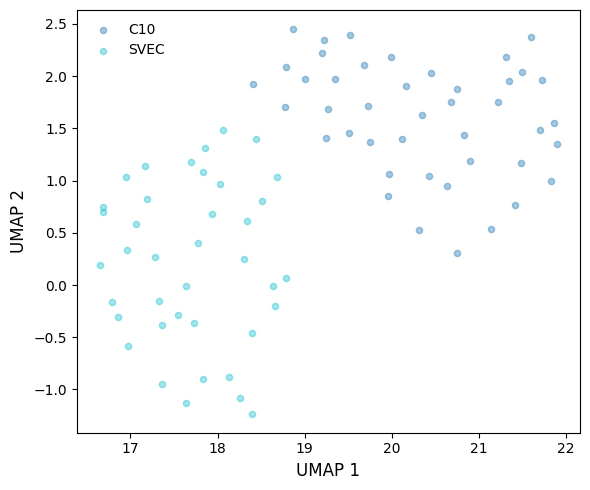

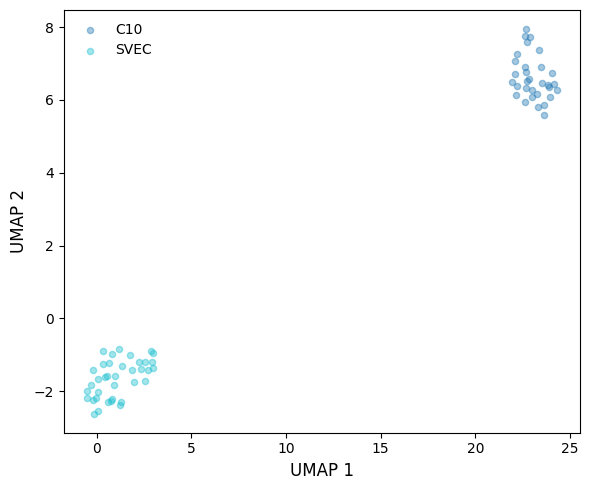

In [17]:
def scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=None, alpha_val=0.4):
    for label in unique_labels:
        mask = labels == label
        if np.any(mask):
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=alpha_val, color=label_to_color[label], label=label)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)

    if panel_label is not None:
        ax.text(-0.14, 1.05, panel_label, transform=ax.transAxes, fontsize=16, fontweight="bold", va="top", ha="left", clip_on=False)

def make_single_embedding(emb, labels, unique_labels, label_to_color, xlabel, ylabel, out_base, panel_label=None, alpha_svg=0.4, alpha_eps=1.0):
    # SVG version
    fig, ax = plt.subplots(figsize=(6, 5))
    scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=panel_label, alpha_val=alpha_svg)
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # EPS version
#    fig, ax = plt.subplots(figsize=(6, 5))
#    scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=panel_label, alpha_val=alpha_eps)
#    ax.legend(loc="best", frameon=False)
#    fig.tight_layout()
#    fig.savefig(f"{out_base}.eps", format="eps", bbox_inches="tight")
#    plt.show()
#    plt.close(fig)

unique_labels = list(np.unique(np.concatenate([rna_labels, prot_labels])))
cmap = plt.get_cmap("tab10", len(unique_labels))
label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}

rna_pca = PCA(n_components=2, random_state=SEED)
rna_2Dpca = rna_pca.fit_transform(rna_mtx)

prot_pca = PCA(n_components=2, random_state=SEED)
prot_2Dpca = prot_pca.fit_transform(prot_mtx)

#UMAP
rna_umap = umap.UMAP(n_components=2, random_state=SEED, transform_seed=SEED)
rna_2Dumap = rna_umap.fit_transform(rna_mtx)

prot_umap = umap.UMAP(n_components=2, random_state=SEED, transform_seed=SEED)
prot_2Dumap = prot_umap.fit_transform(prot_mtx)

make_single_embedding(rna_2Dumap, rna_labels, unique_labels, label_to_color, "UMAP 1", "UMAP 2",
                      os.path.join(OUT_DIR, "RNA_UMAP_before_alignment"))

make_single_embedding(prot_2Dumap, prot_labels, unique_labels, label_to_color, "UMAP 1", "UMAP 2",
                      os.path.join(OUT_DIR, "Proteomics_UMAP_before_alignment"))

In [18]:
# Sinkhorn solver initialisation
scot = SinkhornSolver(nits_uot=5000, tol_uot=1e-3, device=device)

In [21]:
#Function definition
def save_figure_both(fig, out_base):
    fig.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    fig.savefig(f"{out_base}.eps", format="eps", bbox_inches="tight")

In [22]:
RUN_EPS_GRID_SEARCH = False
manual_eps = 4.5e-2

eps_grid = [1e-3, 1e-2, 4.5e-2, 1e-1]
alpha_for_eps = 0.5
k_for_eps = 5

eps_results = []

if RUN_EPS_GRID_SEARCH:
    print("Running epsilon grid search...")

    D_rna_knn_eps = torch.from_numpy(compute_graph_distances(rna_mtx, n_neighbors=k_for_eps, mode="distance").astype("float32")).to(device)

    D_prot_knn_eps = torch.from_numpy(compute_graph_distances(prot_mtx, n_neighbors=k_for_eps, mode="distance").astype("float32")).to(device)

    pi_samp_list = []
    pi_feat_list = []

    for eps_try in eps_grid:
        print(f"\nRunning epsilon test: eps={eps_try}")

        try:
            pi_samp, _, pi_feat = scot.agw(rna_mtx, prot_mtx, D_rna_knn_eps, D_prot_knn_eps, alpha=alpha_for_eps, eps=eps_try, verbose=True)

            pi_samp_list.append((eps_try, pi_samp))
            pi_feat_list.append((eps_try, pi_feat))

            eps_results.append({"eps": eps_try, "status": "success"})

        except Exception as e:
            print(f"Failed for eps={eps_try}: {e}")
            eps_results.append({"eps": eps_try, "status": f"failed: {e}"})

    successful_eps = [x[0] for x in pi_feat_list]
    n_rows = len(successful_eps)
    n_cols = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7 * n_rows), squeeze=False)

    panel_labels = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    panel_idx = 0

    for row_idx, ((eps_try, pi_feat), (_, pi_samp)) in enumerate(zip(pi_feat_list, pi_samp_list)):
        pi_feat_np = pi_feat.detach().cpu().numpy() if hasattr(pi_feat, "detach") else np.array(pi_feat)
        pi_samp_np = pi_samp.detach().cpu().numpy() if hasattr(pi_samp, "detach") else np.array(pi_samp)

        ax1 = axes[row_idx, 0]
        ax2 = axes[row_idx, 1]

        feat_rows = min(100, len(rna_features))
        feat_cols = min(100, len(prot_features))

        sns.heatmap(pd.DataFrame(pi_feat_np[:feat_rows, :feat_cols], index=rna_features[:feat_rows], columns=prot_features[:feat_cols]),
                    cmap="Blues", ax=ax1, cbar=True)
        ax1.set_xlabel("Proteins", fontsize=10)
        ax1.set_ylabel("Genes", fontsize=10)
        ax1.tick_params(axis="x", labelsize=8)
        ax1.tick_params(axis="y", labelsize=8)
        ax1.text(-0.14, 1.05, panel_labels[panel_idx], transform=ax1.transAxes, fontsize=14, fontweight="bold", va="top", ha="left", clip_on=False)
        panel_idx += 1

        n_plot = min(50, pi_samp_np.shape[0], pi_samp_np.shape[1])

        sns.heatmap(pi_samp_np[:n_plot, :n_plot], xticklabels=prot_cells[:n_plot], yticklabels=rna_cells[:n_plot], cmap="Blues", ax=ax2, cbar=True)
        ax2.set_xlabel("Proteomics cells", fontsize=10)
        ax2.set_ylabel("Transcriptomic cells", fontsize=10)
        ax2.tick_params(axis="x", labelsize=8)
        ax2.tick_params(axis="y", labelsize=8)
        ax2.text(-0.14, 1.05, panel_labels[panel_idx], transform=ax2.transAxes, fontsize=14, fontweight="bold", va="top", ha="left", clip_on=False)
        panel_idx += 1

    plt.tight_layout()

    out_base = os.path.join(OUT_DIR, "Supplementary1_epsilon_coupling_heatmaps")
    save_figure_both(fig, out_base)
    plt.show()
    plt.close(fig)

    eps_results_df = pd.DataFrame(eps_results)
    eps_results_df.to_csv(os.path.join(OUT_DIR, "epsilon_grid_search_log.csv"), index=False)

    print("\nEpsilon grid search completed.")
    print("Please inspect the coupling heatmaps and choose eps manually from the tested values.")

    eps = manual_eps
    print(f"Using manually selected eps after grid search: {eps}")

else:
    print("Skipping epsilon grid search. Using manually specified eps.")
    eps = manual_eps

print(f"\nSelected eps for downstream analysis: {eps}")

Skipping epsilon grid search. Using manually specified eps.

Selected eps for downstream analysis: 0.045


In [23]:
def compute_knn_graphs(rna_mtx, prot_mtx, k, device):
    D_rna = torch.from_numpy(compute_graph_distances(rna_mtx, n_neighbors=k, mode="distance").astype("float32")).to(device)
    D_prot = torch.from_numpy(compute_graph_distances(prot_mtx, n_neighbors=k, mode="distance").astype("float32")).to(device)
    return D_rna, D_prot


def add_panel_label(ax, label, x=-0.13, y=1.08, fontsize=16):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=fontsize, fontweight="bold", va="top", ha="left", clip_on=False)


def add_column_header(ax, text, fontsize=12):
    ax.text(0.5, 1.08, text, transform=ax.transAxes, fontsize=fontsize, va="bottom", ha="center", clip_on=False)


def scatter_panel(ax, emb, labels, unique_labels, label_to_color, xlabel, ylabel, panel_label=None, alpha_val=0.4, legend=False):
    for label in unique_labels:
        mask = labels == label
        if np.any(mask):
            ax.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=alpha_val, color=label_to_color[label], label=label)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)

    if panel_label is not None:
        add_panel_label(ax, panel_label)

    if legend:
        ax.legend(loc="best", frameon=False)

def plot_k_alpha_heatmap(ax, pivot_df, panel_label=None):
    plot_df = pivot_df.copy()

    # format column labels to 2 decimal places
    formatted_cols = [f"{float(c):.2f}" for c in plot_df.columns]
    plot_df.columns = formatted_cols

    sns.heatmap(plot_df, annot=True, cmap="viridis_r", ax=ax, cbar=True)

    ax.set_xlabel("alpha", fontsize=12)
    ax.set_ylabel("k (n_neighbors)", fontsize=12)
    ax.tick_params(axis="x", labelrotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    if panel_label is not None:
        add_panel_label(ax, panel_label, x=-0.04, y=1.04)


def plot_rna_before_after_panel(ax, Xrna_pc, Yrna_pc, rna_labels, prot_labels, unique_rna_labels, unique_prot_labels, label_to_color,
                                panel_label=None, alpha_before=0.3, alpha_after=0.7):
    for label in unique_rna_labels:
        mask_before = (rna_labels == label)
        ax.scatter(Xrna_pc[mask_before, 0], Xrna_pc[mask_before, 1], s=25, alpha=alpha_before, color=label_to_color[label], marker="o")

    for label in unique_prot_labels:
        mask_after = (prot_labels == label)
        ax.scatter(Yrna_pc[mask_after, 0], Yrna_pc[mask_after, 1], s=30, alpha=alpha_after, color=label_to_color[label], marker="^")

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

    if panel_label is not None:
        add_panel_label(ax, panel_label)


def plot_aligned_on_protein_panel(ax, prot_2Dpca, aligned_rna_prot_pca, prot_labels, rna_labels, unique_labels, label_to_color,
                                  panel_label=None, alpha_prot=0.6, alpha_aligned=0.4):
    for label in unique_labels:
        mask_prot = (prot_labels == label)
        mask_rna = (rna_labels == label)

        ax.scatter(prot_2Dpca[mask_prot, 0], prot_2Dpca[mask_prot, 1], s=25, alpha=alpha_prot, color=label_to_color[label], marker="o")

        ax.scatter(aligned_rna_prot_pca[mask_rna, 0], aligned_rna_prot_pca[mask_rna, 1], s=30, alpha=alpha_aligned, color=label_to_color[label],
                   marker="^")

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

    if panel_label is not None:
        add_panel_label(ax, panel_label)

def build_figure2(out_base, rna_2Dpca, prot_2Dpca, rna_labels, prot_labels, unique_labels, unique_rna_labels, unique_prot_labels, label_to_color,
                  selected_alpha_panels, fracs, rand_fracs, mean_fos, mean_rand, alpha_scatter_main=0.4, alpha_before=0.3, alpha_after=0.7,
                  alpha_prot=0.6, alpha_aligned=0.4, color_legend_anchor=(0.34, 0.985), shape_legend_anchor=(0.73, 0.985), save_svg=True,
                  save_eps=True):
    
#    handles_color = [Line2D([], [], linestyle="", marker="o", markersize=6, color=label_to_color[label], label=label) for label in unique_labels]

#    handles_shape = [Line2D([], [], linestyle="", marker="o", color="black", markersize=6, label="Original"),
#                     Line2D([], [], linestyle="", marker="^", color="black", markersize=6, label="Aligned")]

    handles_color = [Line2D([], [], linestyle="", marker="o", markersize=6, color=label_to_color[label], label=label) for label in unique_labels]
    handles_shape = [Line2D([], [], linestyle="", marker="o", color="black", markersize=6, label="Before"), 
                     Line2D([], [], linestyle="", marker="^", color="black", markersize=6, label="After")]
    combined_handles = handles_color + handles_shape
    combined_labels = [h.get_label() for h in combined_handles]
    
    
    handles_fos = [Line2D([], [], linestyle="--", color="black", label=f"AGW alignment (mean={mean_fos:.3f})"),
                   Line2D([], [], linestyle=":", color="black", label=f"Random alignment (mean={mean_rand:.3f})")]

    def plot_foscttm_panel(ax, fracs, rand_fracs, panel_label=None):
        ax.plot(np.arange(len(fracs)), np.sort(fracs), linestyle="--")
        ax.plot(np.arange(len(rand_fracs)), np.sort(rand_fracs), linestyle=":")
        ax.set_xlabel("Cells", fontsize=12)
        ax.set_ylabel("Sorted FOSCTTM", fontsize=12)
        ax.tick_params(labelsize=10)

        if panel_label is not None:
            add_panel_label(ax, panel_label, x=-0.05, y=1.04)

    def _draw_one_figure(scatter_alpha_main, before_alpha, after_alpha, prot_alpha, aligned_alpha):
        fig = plt.figure(figsize=(14, 17))
        gs = GridSpec(nrows=4, ncols=6, figure=fig, height_ratios=[1.05, 1.05, 1.05, 1.0], hspace=0.45, wspace=0.8)

        # A, B
        axA = fig.add_subplot(gs[0, 0:2])
        axB = fig.add_subplot(gs[0, 2:4])

        scatter_panel(axA, rna_2Dpca, rna_labels, unique_labels, label_to_color, None, None, panel_label="A", alpha_val=scatter_alpha_main,
                      legend=False)
        scatter_panel(axB, prot_2Dpca, prot_labels, unique_labels, label_to_color, None, None, panel_label="B", alpha_val=scatter_alpha_main,
                      legend=False)

        # C-H
        alpha_order = [0.9, 0.6, 0.3]
        panel_letters_top = ["C", "D", "E"]
        panel_letters_bottom = ["F", "G", "H"]

        top_axes = [fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4]), fig.add_subplot(gs[1, 4:6])]
        bottom_axes = [fig.add_subplot(gs[2, 0:2]), fig.add_subplot(gs[2, 2:4]), fig.add_subplot(gs[2, 4:6])]

        for i, alpha_val in enumerate(alpha_order):
            panel_data = selected_alpha_panels[alpha_val]

#            add_column_header(top_axes[i], rf"$\alpha = {alpha_val}$", fontsize=12)

            plot_rna_before_after_panel(top_axes[i], panel_data["Xrna_pc"], panel_data["Yrna_pc"], rna_labels, prot_labels,
                                        unique_rna_labels, unique_prot_labels, label_to_color, panel_label=panel_letters_top[i],
                                        alpha_before=before_alpha, alpha_after=after_alpha)

            plot_aligned_on_protein_panel(bottom_axes[i], prot_2Dpca, panel_data["aligned_rna_prot_pca"], prot_labels, rna_labels,
                                          unique_labels, label_to_color, panel_label=panel_letters_bottom[i], alpha_prot=prot_alpha,
                                          alpha_aligned=aligned_alpha)

        #I
        axI = fig.add_subplot(gs[3, 0:6])
        plot_foscttm_panel(axI, fracs, rand_fracs, panel_label="I")
        
        # legends at figure level
#        fig.legend(handles=handles_color, labels=unique_labels, loc="upper center", bbox_to_anchor=color_legend_anchor, ncol=len(unique_labels),
#                   frameon=False, fontsize=11)

#        fig.legend(handles=handles_shape, labels=["Before", "After"], loc="upper center", bbox_to_anchor=shape_legend_anchor, ncol=2,
#                   frameon=False, fontsize=11)

        fig.legend(handles=combined_handles, labels=combined_labels, loc="center left", bbox_to_anchor=(0.75, 0.82), ncol=1,
                   frameon=True, fontsize=12, borderaxespad=0.0)
        
        axI.legend(handles=handles_fos, loc="best", frameon=False, fontsize=10)

        fig.text(0.5, 0.29, "Principal Component 1", ha="center", va="center", fontsize=13)
        fig.text(0.08, 0.56, "Principal Component 2", ha="center", va="center", rotation="vertical", fontsize=13)
        
        return fig

    # SVG figure
    if save_svg:
        fig_svg = _draw_one_figure(scatter_alpha_main=alpha_scatter_main, before_alpha=alpha_before, after_alpha=alpha_after, prot_alpha=alpha_prot,
                                   aligned_alpha=alpha_aligned)
    fig_svg.savefig(f"{out_base}.svg", format="svg", bbox_inches="tight")
    plt.show()
    plt.close(fig_svg)

    # EPS figure
    if save_eps:
        # use opaque markers in EPS to avoid transparency problems
        fig_eps = _draw_one_figure(scatter_alpha_main=1.0, before_alpha=1.0, after_alpha=1.0, prot_alpha=1.0, aligned_alpha=1.0)
        fig_eps.savefig(f"{out_base}.eps", format="eps", bbox_inches="tight")
        plt.show()
        plt.close(fig_eps)

In [24]:
#Existing PCA / labels setup
unique_labels = list(np.unique(np.concatenate([rna_labels, prot_labels])))
unique_rna_labels = np.unique(rna_labels)
unique_prot_labels = np.unique(prot_labels)

cmap = plt.get_cmap("tab10", len(unique_labels))
label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}

#Grid search settings
RUN_GRID_SEARCH = True
manual_k = 10
alpha_compare = [0.9, 0.6, 0.3]
k_grid = [5, 10, 15, 20]
alpha_grid = np.linspace(0.01, 0.99, 10)

#Shared index maps for FOSCTTM
rna_idx_map = {sid: i for i, sid in enumerate(rna_cells)}
prot_idx_map = {sid: i for i, sid in enumerate(prot_cells)}

rna_common_idx = np.array([rna_idx_map[sid] for sid in common_true])
prot_common_idx = np.array([prot_idx_map[sid] for sid in common_true])

results_df = pd.DataFrame()

#Grid search over k and alpha using FOSCTTM
if RUN_GRID_SEARCH:
    print("Running grid search over k and alpha...")

    results = []

    for k in k_grid:
        print(f"\nEvaluating k = {k}")
        D_rna_knn, D_prot_knn = compute_knn_graphs(rna_mtx, prot_mtx, k, device)

        for alpha in alpha_grid:
            try:
                pi_samp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_knn, D_prot_knn, alpha=alpha, eps=eps, verbose=False)

                aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
                aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

                rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
                prot_common = prot_mtx[prot_common_idx, :]

                fracs = FOSCTTM(prot_common, rna_common)
                mean_fos = float(np.mean(fracs))

                results.append({"k": k, "alpha": float(alpha), "foscttm": mean_fos})

                print(f"k={k}, alpha={alpha:.3f}, FOSCTTM={mean_fos:.4f}")

            except Exception as e:
                print(f"Failed for k={k}, alpha={alpha}: {e}")

    results_df = pd.DataFrame(results)

    if results_df.empty:
        raise RuntimeError("Grid search ran but produced no valid results.")

    results_df.to_csv(os.path.join(OUT_DIR, "k_alpha_grid_search.csv"), index=False)

    best_row = results_df.loc[results_df["foscttm"].idxmin()]
    best_k = int(best_row["k"])
    print("\nBest k from grid search:", best_k)

else:
    print("Skipping grid search. Using manually specified k.")
    best_k = manual_k

print(f"\nSelected k for downstream comparisons: {best_k}")
print(f"Fixed eps: {eps}")

#Build pivot heatmap using the selected k
if results_df.empty:
    # If no grid search run in this session, compute the full k x alpha heatmap
    heatmap_results = []

    print("\nComputing full k x alpha heatmap values...")
    for k in k_grid:
        D_rna_heat, D_prot_heat = compute_knn_graphs(rna_mtx, prot_mtx, k, device)

        for alpha in alpha_grid:
            try:
                pi_samp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_heat, D_prot_heat, alpha=alpha, eps=eps, verbose=False)

                aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
                aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

                rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
                prot_common = prot_mtx[prot_common_idx, :]

                fracs = FOSCTTM(prot_common, rna_common)
                mean_fos = float(np.mean(fracs))

                heatmap_results.append({"k": k, "alpha": float(alpha), "foscttm": mean_fos})

            except Exception as e:
                print(f"Failed for k={k}, alpha={alpha}: {e}")

    heatmap_df = pd.DataFrame(heatmap_results)
else:
    heatmap_df = results_df.copy()

if heatmap_df.empty:
    raise RuntimeError("No valid alpha heatmap results available for Figure 2C.")

pivot = (heatmap_df.sort_values(["k", "alpha"]).pivot(index="k", columns="alpha", values="foscttm"))

Running grid search over k and alpha...

Evaluating k = 5
k=5, alpha=0.010, FOSCTTM=0.4167
k=5, alpha=0.119, FOSCTTM=0.3919
k=5, alpha=0.228, FOSCTTM=0.3839
k=5, alpha=0.337, FOSCTTM=0.3320
k=5, alpha=0.446, FOSCTTM=0.3120
k=5, alpha=0.554, FOSCTTM=0.3008
k=5, alpha=0.663, FOSCTTM=0.2848
k=5, alpha=0.772, FOSCTTM=0.2675
k=5, alpha=0.881, FOSCTTM=0.2533
k=5, alpha=0.990, FOSCTTM=0.2568

Evaluating k = 10
k=10, alpha=0.010, FOSCTTM=0.4139
k=10, alpha=0.119, FOSCTTM=0.3975
k=10, alpha=0.228, FOSCTTM=0.3805
k=10, alpha=0.337, FOSCTTM=0.3332
k=10, alpha=0.446, FOSCTTM=0.3105
k=10, alpha=0.554, FOSCTTM=0.3105
k=10, alpha=0.663, FOSCTTM=0.3020
k=10, alpha=0.772, FOSCTTM=0.2794
k=10, alpha=0.881, FOSCTTM=0.2653
k=10, alpha=0.990, FOSCTTM=0.2477

Evaluating k = 15
k=15, alpha=0.010, FOSCTTM=0.4186
k=15, alpha=0.119, FOSCTTM=0.4134
k=15, alpha=0.228, FOSCTTM=0.3825
k=15, alpha=0.337, FOSCTTM=0.3477
k=15, alpha=0.446, FOSCTTM=0.3180
k=15, alpha=0.554, FOSCTTM=0.3077
k=15, alpha=0.663, FOSCTTM=0.2

In [25]:
#Alpha comparison diagnostics
alpha_plot_dir = os.path.join(OUT_DIR, "alpha_comparison_plots")
os.makedirs(alpha_plot_dir, exist_ok=True)

D_rna_cmp, D_prot_cmp = compute_knn_graphs(rna_mtx, prot_mtx, best_k, device)

alpha_summary = []
selected_alphas = [0.9, 0.6, 0.3]
selected_alpha_panels = {}

for alpha_cmp in alpha_compare:
    print(f"\nGenerating comparison data for alpha = {alpha_cmp}")

    pi_samp_cmp, _, _ = scot.agw(rna_mtx, prot_mtx, D_rna_cmp, D_prot_cmp, alpha=alpha_cmp, eps=eps, verbose=False)

    # RNA feature space on proteomics sample axis
    aligned_rna_rna_space = get_barycentre(rna_mtx, pi_samp_cmp.T, device=device)
    aligned_rna_rna_space_np = aligned_rna_rna_space.detach().cpu().numpy()

    # Protein feature space on RNA sample axis
    aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp_cmp, device=device)
    aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

    # FOSCTTM
    rna_common_cmp = aligned_rna_prot_space_np[rna_common_idx, :]
    prot_common_cmp = prot_mtx[prot_common_idx, :]

    fracs_cmp = FOSCTTM(prot_common_cmp, rna_common_cmp)
    mean_fos_cmp = float(np.mean(fracs_cmp))

    alpha_summary.append({"alpha": alpha_cmp, "k": best_k, "eps": eps, "foscttm": mean_fos_cmp})

    # Project into PCA spaces
    Xrna_pc = rna_pca.transform(rna_mtx)
    Yrna_pc = rna_pca.transform(aligned_rna_rna_space_np)
    aligned_rna_prot_pca = prot_pca.transform(aligned_rna_prot_space_np)

    # Save selected panels for Figure 2D-I
    if alpha_cmp in selected_alphas:
        selected_alpha_panels[alpha_cmp] = {"Xrna_pc": Xrna_pc, "Yrna_pc": Yrna_pc, "aligned_rna_prot_pca": aligned_rna_prot_pca}

    # Optional: save standalone 2-panel diagnostic figures for each alpha
    for ext in ["svg", "eps"]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        scatter_before = 0.3 if ext == "svg" else 1.0
        scatter_after = 0.7 if ext == "svg" else 1.0
        scatter_prot = 0.6 if ext == "svg" else 1.0
        scatter_aligned = 0.4 if ext == "svg" else 1.0

        plot_rna_before_after_panel(axes[0], Xrna_pc, Yrna_pc, rna_labels, prot_labels, unique_rna_labels, unique_prot_labels, label_to_color,
                                    alpha_before=scatter_before, alpha_after=scatter_after)

        plot_aligned_on_protein_panel(axes[1], prot_2Dpca, aligned_rna_prot_pca, prot_labels, rna_labels, unique_labels, label_to_color,
                                      alpha_prot=scatter_prot, alpha_aligned=scatter_aligned)

        fig.tight_layout()
        fig.savefig(os.path.join(alpha_plot_dir, f"alpha_{alpha_cmp}_comparison.{ext}"), format=ext, bbox_inches="tight")
        plt.close(fig)

alpha_summary_df = pd.DataFrame(alpha_summary)
alpha_summary_df.to_csv(os.path.join(alpha_plot_dir, "alpha_comparison_summary.csv"), index=False)

print("\nAlpha comparison summary:")
print(alpha_summary_df)

missing_needed = [a for a in selected_alphas if a not in selected_alpha_panels]
if missing_needed:
    raise RuntimeError(f"Missing selected alpha panels for Figure 2: {missing_needed}")


Generating comparison data for alpha = 0.9

Generating comparison data for alpha = 0.6

Generating comparison data for alpha = 0.3

Alpha comparison summary:
   alpha   k    eps   foscttm
0    0.9  10  0.045  0.262842
1    0.6  10  0.045  0.306967
2    0.3  10  0.045  0.363661



Running final alignment with selected parameters:
eps = 0.045
k = 10
alpha = 0.6
BCD Iteration 1 - Loss: 0.764336, 0.812731
BCD Iteration 2 - Loss: 0.735820, 0.801227
BCD Iteration 3 - Loss: 0.726422, 0.799406
BCD Iteration 4 - Loss: 0.720626, 0.798357
BCD Iteration 5 - Loss: 0.716690, 0.797577
BCD Iteration 6 - Loss: 0.714544, 0.797193
BCD Iteration 7 - Loss: 0.713106, 0.796972
BCD Iteration 8 - Loss: 0.711565, 0.796709
BCD Iteration 9 - Loss: 0.709889, 0.796458
BCD Iteration 10 - Loss: 0.708790, 0.796356
BCD Iteration 11 - Loss: 0.707913, 0.796279
BCD Iteration 12 - Loss: 0.707027, 0.796201
BCD Iteration 13 - Loss: 0.706305, 0.796152
BCD Iteration 14 - Loss: 0.705799, 0.796122
BCD Iteration 15 - Loss: 0.705401, 0.796095

Running final FOSCTTM evaluation...
Mean FOSCTTM: 0.306967213114754
Random baseline: 0.5913934426229507


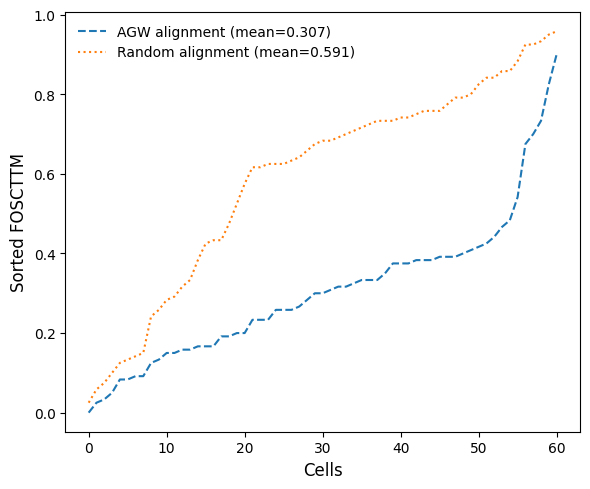

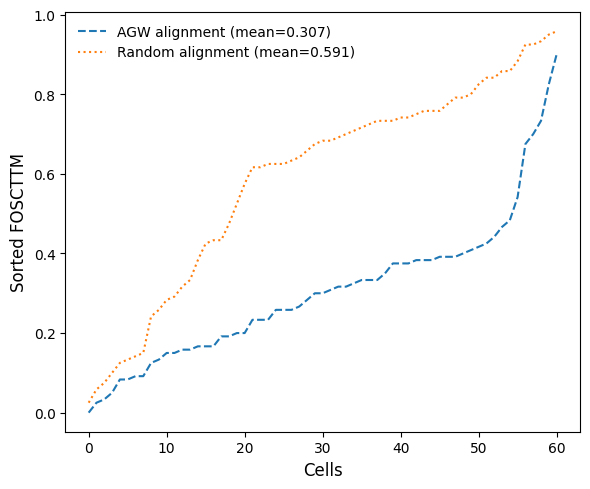

In [26]:
# Final alignment, define alpha after inspecting the alpha comparison plots
final_alpha = 0.6

# Safety check
if not (0 <= final_alpha <= 1):
    raise ValueError(f"final_alpha must be between 0 and 1, got {final_alpha}")

if final_alpha not in alpha_compare:
    print(f"Warning: final_alpha={final_alpha} was not included in alpha_compare={alpha_compare}")

print("\nRunning final alignment with selected parameters:")
print(f"eps = {eps}")
print(f"k = {best_k}")
print(f"alpha = {final_alpha}")

#Recompute graph distances using the selected k
D_rna_knn, D_prot_knn = compute_knn_graphs(rna_mtx, prot_mtx, best_k, device)

#Run final AGW alignment
pi_samp, _, pi_feat = scot.agw(rna_mtx, prot_mtx, D_rna_knn, D_prot_knn, alpha=final_alpha, eps=eps, verbose=True)

#FOSCTTM evaluation based on the selected alpha
print("\nRunning final FOSCTTM evaluation...")

#Aligned RNA in protein feature space on RNA sample axis
aligned_rna_prot_space = get_barycentre(prot_mtx, pi_samp, device=device)
aligned_rna_prot_space_np = aligned_rna_prot_space.detach().cpu().numpy()

#Compute FOSCTTM on true paired samples
rna_common = aligned_rna_prot_space_np[rna_common_idx, :]
prot_common = prot_mtx[prot_common_idx, :]

fracs = FOSCTTM(prot_common, rna_common)
mean_fos = float(np.mean(fracs))

# Random baseline
perm = np.random.permutation(len(prot_common))
rand_fracs = FOSCTTM(prot_common[perm], rna_common)
mean_rand = float(np.mean(rand_fracs))

print("Mean FOSCTTM:", mean_fos)
print("Random baseline:", mean_rand)

# Standalone FOSCTTM plot
for ext in ["svg", "eps"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(np.arange(len(fracs)), np.sort(fracs), linestyle="--", label=f"AGW alignment (mean={mean_fos:.3f})")
    ax.plot(np.arange(len(rand_fracs)), np.sort(rand_fracs), linestyle=":", label=f"Random alignment (mean={mean_rand:.3f})")
    ax.set_xlabel("Cells", fontsize=12)
    ax.set_ylabel("Sorted FOSCTTM", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.legend(frameon=False, fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"FOSCTTM_final.{ext}"), format=ext, bbox_inches="tight")
    plt.show()
    plt.close(fig)

final_foscttm_df = pd.DataFrame([{"alpha": final_alpha, "k": best_k, "eps": eps, "mean_foscttm": mean_fos, "random_baseline": mean_rand}])

final_foscttm_df.to_csv(os.path.join(OUT_DIR, "final_foscttm_summary.csv"), index=False)

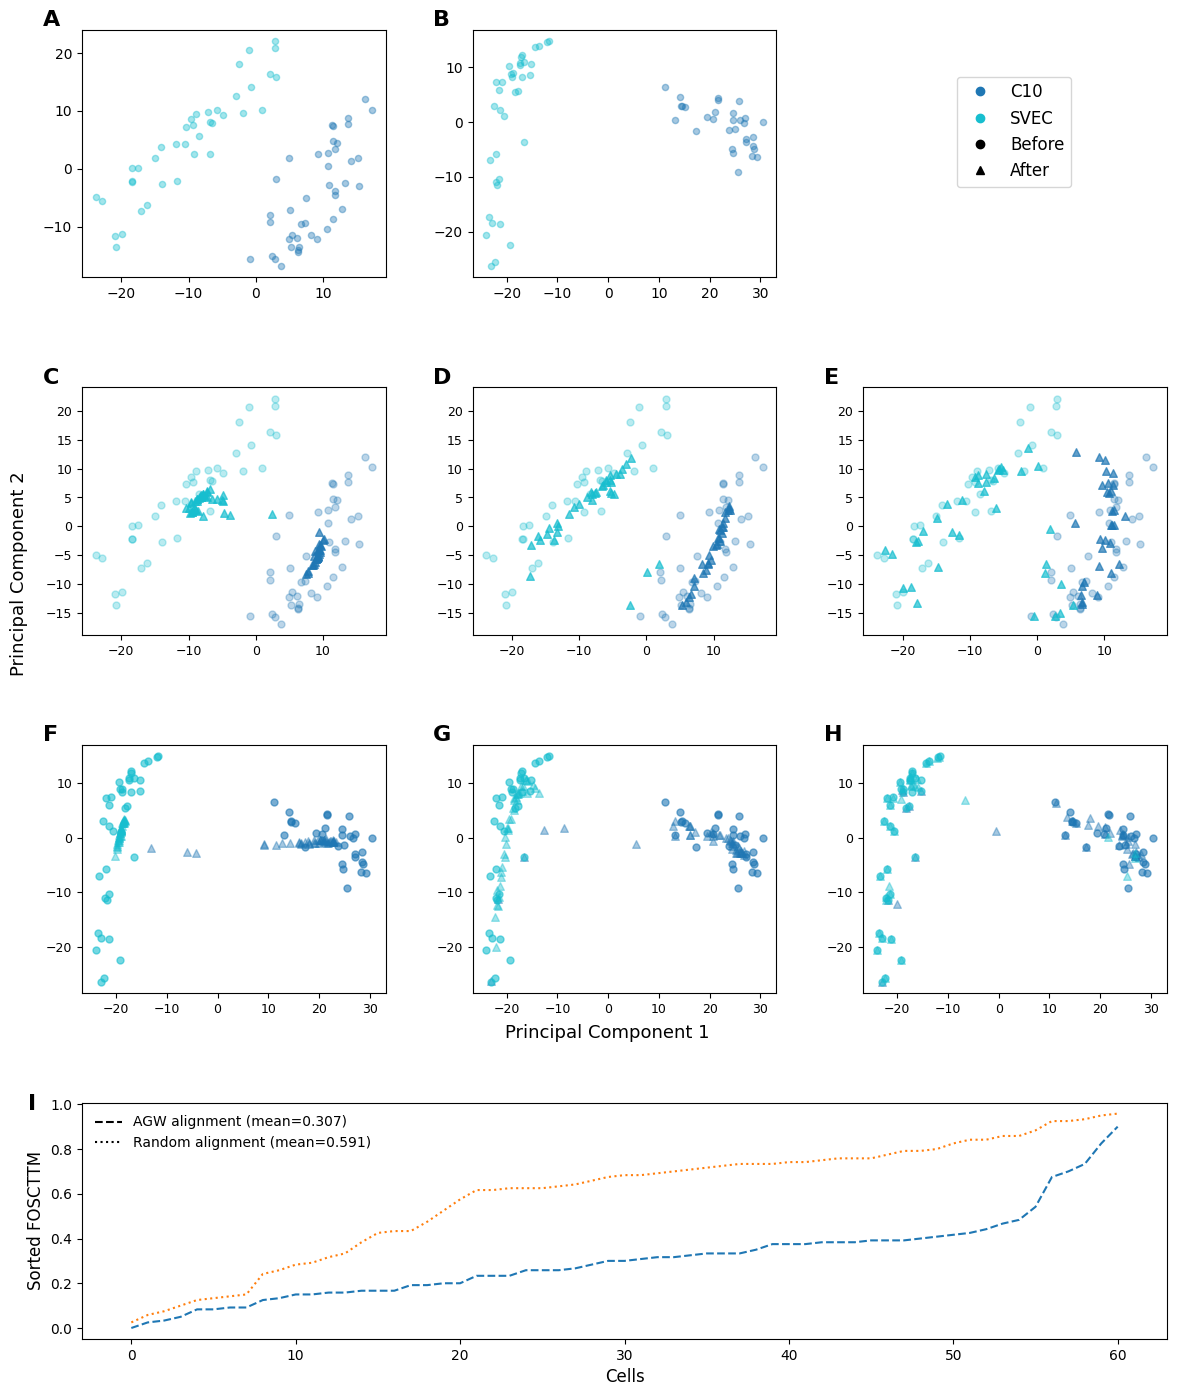

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


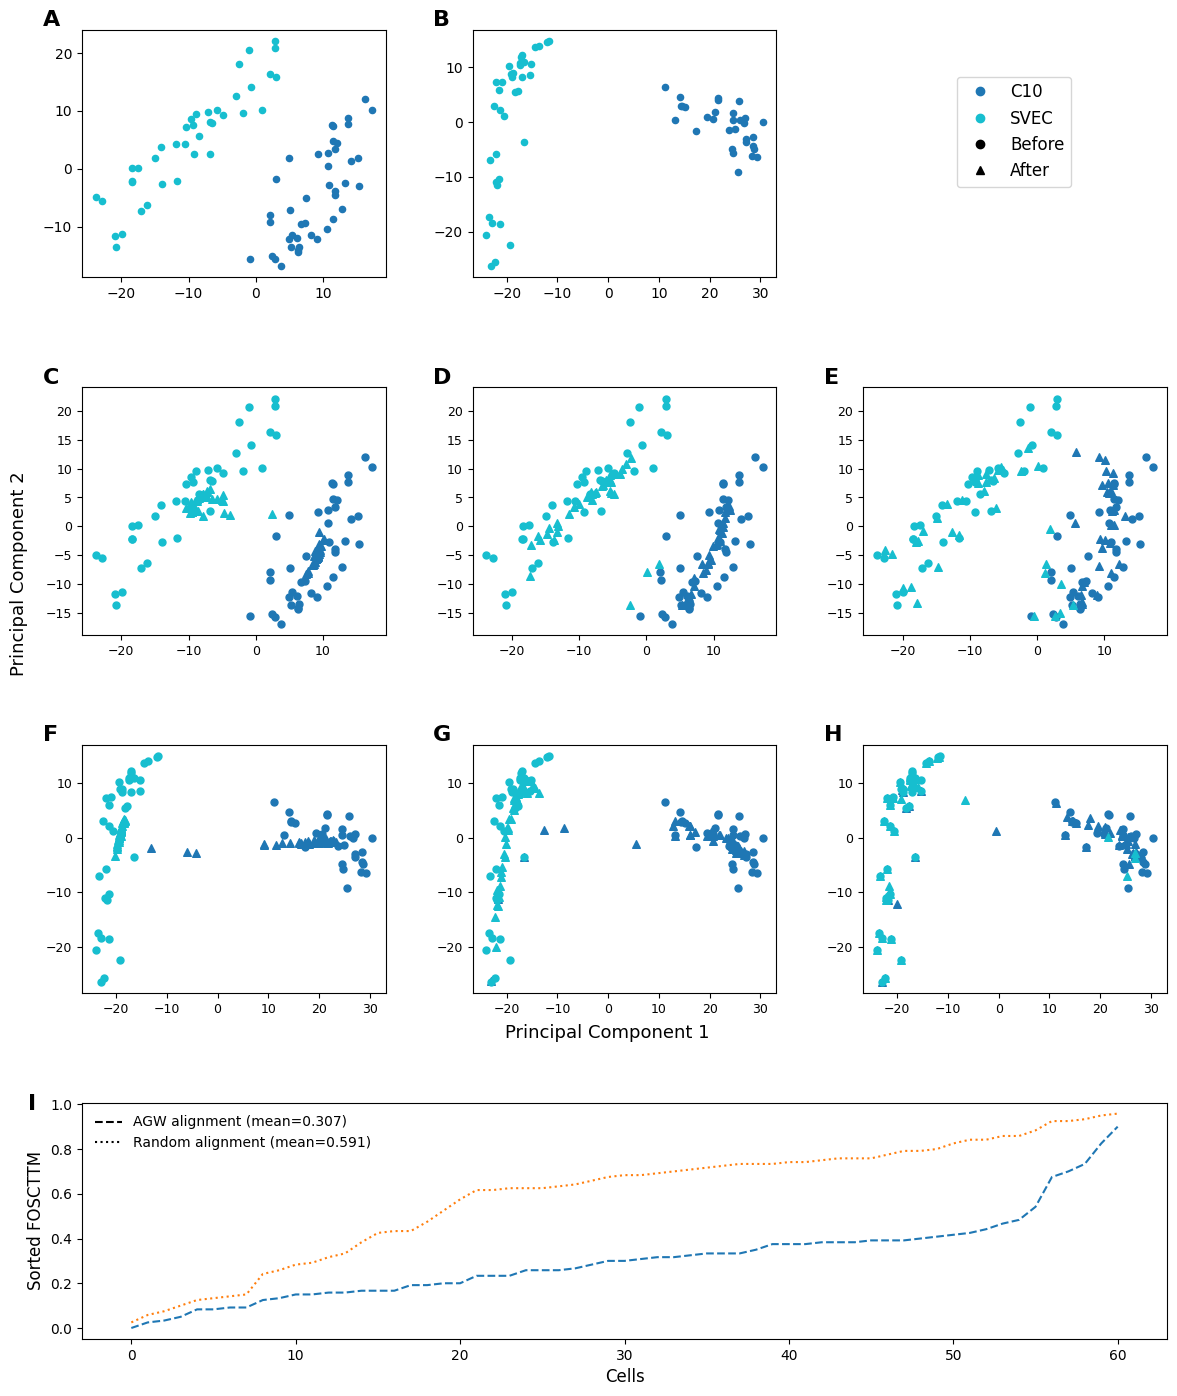

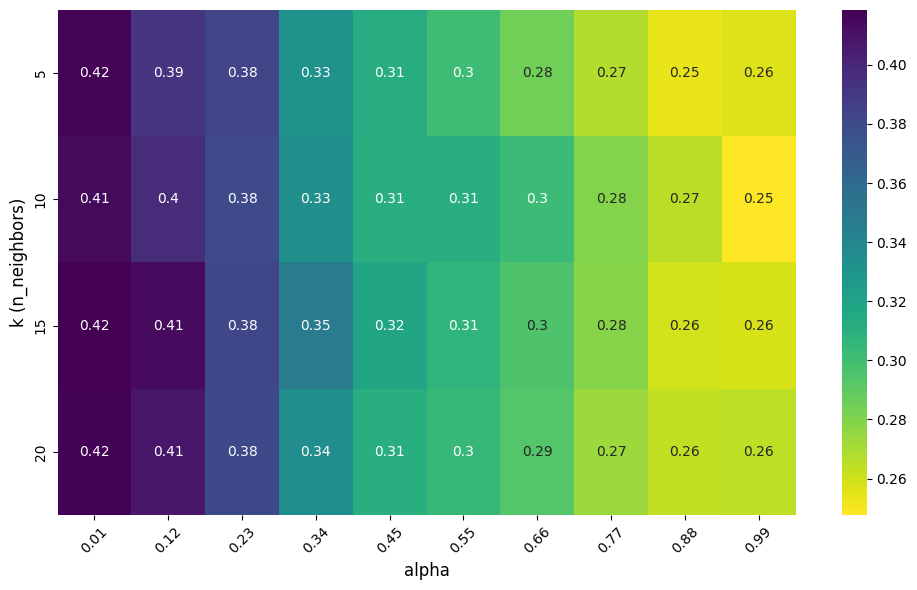

In [27]:
#Figure 2
build_figure2(out_base=os.path.join(OUT_DIR, "Figure1"), rna_2Dpca=rna_2Dpca, prot_2Dpca=prot_2Dpca, rna_labels=rna_labels, prot_labels=prot_labels,
              unique_labels=unique_labels, unique_rna_labels=unique_rna_labels, unique_prot_labels=unique_prot_labels, label_to_color=label_to_color,
              selected_alpha_panels=selected_alpha_panels, fracs=fracs, rand_fracs=rand_fracs, mean_fos=mean_fos, mean_rand=mean_rand, alpha_scatter_main=0.4,
              alpha_before=0.3, alpha_after=0.7, alpha_prot=0.6, alpha_aligned=0.4, color_legend_anchor=(0.34, 0.92), shape_legend_anchor=(0.73, 0.92),
              save_svg=True, save_eps=True)
#Supplementary figure 2 - heatmap
fig, ax = plt.subplots(figsize=(10, 6))
plot_k_alpha_heatmap(ax, pivot, panel_label=None)
fig.tight_layout()
save_figure_both(fig, os.path.join(OUT_DIR, "Supplementary_Figure_S2_k_alpha_heatmap"))
plt.show()
plt.close(fig)

In [28]:
# Preparation of MOFA matrices
print("\nPreparing MOFA-ready matrices...")

# RNA projected onto proteomics sample axis, retaining RNA features
rna_on_prot_sample_axis = get_barycentre(rna_mtx, pi_samp.T, device=device)
rna_on_prot_sample_axis_np = rna_on_prot_sample_axis.detach().cpu().numpy()

# Build RNA dataframe
aligned_rna_df = pd.DataFrame(rna_on_prot_sample_axis_np, index=prot_cells, columns=rna_features).T

# Proteomics dataframe
prot_df_for_mofa = pd.DataFrame(prot_mtx, index=prot_cells, columns=prot_features).T
print("\nMOFA-ready aligned RNA shape (features x samples):", aligned_rna_df.shape)
print("MOFA-ready proteomics shape (features x samples):", prot_df_for_mofa.shape)

# Consistency check
if not aligned_rna_df.columns.equals(prot_df_for_mofa.columns):
    raise ValueError("Aligned RNA and proteomics views do not share identical sample axis for MOFA.")

# Centering, since MOFA expects roughly centered Gaussian data
aligned_rna_centered = aligned_rna_df.sub(aligned_rna_df.mean(axis=1), axis=0).astype(np.float32)
prot_centered = prot_df_for_mofa.sub(prot_df_for_mofa.mean(axis=1), axis=0).astype(np.float32)


Preparing MOFA-ready matrices...

MOFA-ready aligned RNA shape (features x samples): (1500, 68)
MOFA-ready proteomics shape (features x samples): (1500, 68)


In [29]:
# Export MOFA inputs
print("\nExporting MOFA inputs and alignment outputs...")
aligned_rna_centered.to_csv(os.path.join(OUT_DIR, "aligned_transcriptomics.csv"), index_label="Gene")

prot_centered.to_csv(os.path.join(OUT_DIR, "aligned_proteomics.csv"), index_label="Gene")

# Metadata alignment
if "SampleID" in prot_meta.columns:
    prot_meta_indexed = prot_meta.set_index("SampleID")
else:
    prot_meta_indexed = prot_meta.copy()

# Align metadata to proteomics sample axis
missing_samples = set(prot_cells) - set(prot_meta_indexed.index)
if len(missing_samples) > 0:
    raise ValueError(f"Missing metadata for samples: {missing_samples}")

aligned_metadata = prot_meta_indexed.loc[prot_cells].copy()
aligned_metadata.index.name = "SampleID"
aligned_metadata.to_csv(os.path.join(OUT_DIR, "aligned_metadata.csv"))

# Save coupling matrices
pi_samp_np = pi_samp.detach().cpu().numpy()
pi_feat_np = pi_feat.detach().cpu().numpy()

pd.DataFrame(pi_samp_np, index=rna_cells, columns=prot_cells).to_csv(os.path.join(OUT_DIR, "sample_coupling_matrix.csv"))

pd.DataFrame(pi_feat_np, index=rna_features, columns=prot_features).to_csv(os.path.join(OUT_DIR, "feature_coupling_matrix.csv"))

# Save final parameters
final_config = pd.DataFrame([{
    "alpha": final_alpha,
    "k": best_k,
    "eps": eps,
    "n_rna_cells": len(rna_cells),
    "n_prot_cells": len(prot_cells),
    "n_common_pairs": len(common_true)
}])

final_config.to_csv(os.path.join(OUT_DIR, "scot_alignment_config.csv"), index=False)

print("\nSCOT+ alignment complete.")
print("Saved MOFA-ready files to:", OUT_DIR)
print("Saved alignment diagnostics and configuration.")


Exporting MOFA inputs and alignment outputs...

SCOT+ alignment complete.
Saved MOFA-ready files to: C:\Users\49152\Downloads\Multi-omics\Script\For_repositories\aligned_data
Saved alignment diagnostics and configuration.
